# ⏳ 09 — Temporal Feature Engineering & Analysis

This notebook focuses on capturing the **seasonality** and **cyclical patterns** in air quality data.
Previous models (Linear, RF, LightGBM) treated each row independently, missing the crucial context that "Winter usually has worse air quality than Summer".

**Key Objectives**:
1.  **Visual Verification**: Use Boxplots to visualize the distribution of AQI across different time scales.
2.  **Feature Impact**: Confirm that [season](cci:1://file:///c:/Users/dinni/OneDrive/%E6%A1%8C%E9%9D%A2/air_pollution/src/utils/time_utils.py:56:4-64:27) and `month` are strong indicators of AQI levels.

## 🧠 01 — Notebook Metadata
Basic setup information and environment initialization for this analysis.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.config import PROCESSED_DIR, TITLE_FONT_SIZE, FONT_SIZE
from src.utils.emoji_log import task
from src.features.feature_engineering import add_time_features

sns.set_theme(style="whitegrid")

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

## 🧱 02 — Load Processed Data

Load the `full_data.parquet` which has been processed by our updated pipeline

In [3]:
parquet_path = PROCESSED_DIR / "full_data.parquet"
df = pd.read_parquet(parquet_path)
df

,date,sitename,county,aqi,status,so2,co,o3,o3_8hr,pm10,...,winddirec,co_8hr,longitude,latitude,year,month,day,weekday,hour,season
0,2024-08-31 23:00:00,Hukou,Hsinchu_County,62.0,Moderate,0.9,0.17,35.0,40.2,18.0,...,225.0,0.20,121.038869,24.900097,2024,8,31,5,23,Summer
1,2024-08-31 23:00:00,Zhongming,Taichung_City,50.0,Good,1.6,0.32,27.9,35.1,27.0,...,184.0,0.20,120.641092,24.151958,2024,8,31,5,23,Summer
2,2024-08-31 23:00:00,Zhudong,Hsinchu_County,45.0,Good,0.4,0.17,25.1,40.6,21.0,...,210.0,0.20,121.088955,24.740914,2024,8,31,5,23,Summer
3,2024-08-31 23:00:00,Hsinchu,Hsinchu_City,42.0,Good,0.8,0.20,30.0,35.9,19.0,...,239.0,0.20,120.972368,24.805636,2024,8,31,5,23,Summer
4,2024-08-31 23:00:00,Toufen,Miaoli_County,50.0,Good,1.0,0.16,33.5,35.9,18.0,...,259.0,0.10,120.898693,24.696907,2024,8,31,5,23,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5823857,2016-11-25 13:00:00,Daliao,Kaohsiung_City,77.0,Moderate,8.0,0.54,36.0,12.0,69.0,...,202.0,0.63,120.321268,22.654831,2016,11,25,4,13,Autumn
5823858,2016-11-25 13:00:00,Linyuan,Kaohsiung_City,77.0,Moderate,4.6,0.31,94.0,41.0,30.0,...,224.0,0.46,120.321268,22.654831,2016,11,25,4,13,Autumn
5823859,2016-11-25 13:00:00,Nanzi,Kaohsiung_City,74.0,Moderate,4.2,0.30,90.0,31.0,136.0,...,242.0,0.41,120.321268,22.654831,2016,11,25,4,13,Autumn
5823860,2016-11-25 13:00:00,Zuoying,Kaohsiung_City,99.0,Moderate,6.7,0.62,115.0,40.0,108.0,...,280.0,0.63,120.321268,22.654831,2016,11,25,4,13,Autumn


In [6]:
df["date"] = pd.to_datetime(df["date"])
df.dtypes

date         datetime64[ns]
sitename             object
county               object
aqi                 float64
status               object
so2                 float64
co                  float64
o3                  float64
o3_8hr              float64
pm10                float64
pm2.5               float64
no2                 float64
nox                 float64
no                  float64
windspeed           float64
winddirec           float64
co_8hr              float64
longitude           float64
latitude            float64
year                  int64
month                 int64
day                   int64
weekday               int64
hour                  int64
season               object
dtype: object

In [9]:
task("Generating temporal features...")
df = add_time_features(df)
df.shape

🚀 Generating temporal features...
✅ Season encoded successfully.


(5823862, 26)

In [10]:
cols_to_check = ["date", "month", "season", "season_encoded", "aqi"]
df[cols_to_check]

,date,month,season,season_encoded,aqi
0,2024-08-31 23:00:00,8,Summer,2,62.0
1,2024-08-31 23:00:00,8,Summer,2,50.0
2,2024-08-31 23:00:00,8,Summer,2,45.0
3,2024-08-31 23:00:00,8,Summer,2,42.0
4,2024-08-31 23:00:00,8,Summer,2,50.0
...,...,...,...,...,...
5823857,2016-11-25 13:00:00,11,Autumn,3,77.0
5823858,2016-11-25 13:00:00,11,Autumn,3,77.0
5823859,2016-11-25 13:00:00,11,Autumn,3,74.0
5823860,2016-11-25 13:00:00,11,Autumn,3,99.0


## 📊 03 — Monthly Seasonality Analysis

We hypothesize that specific months (e.g., Jan, Feb) have significantly higher AQI due to weather patterns (Northeast Monsoon).

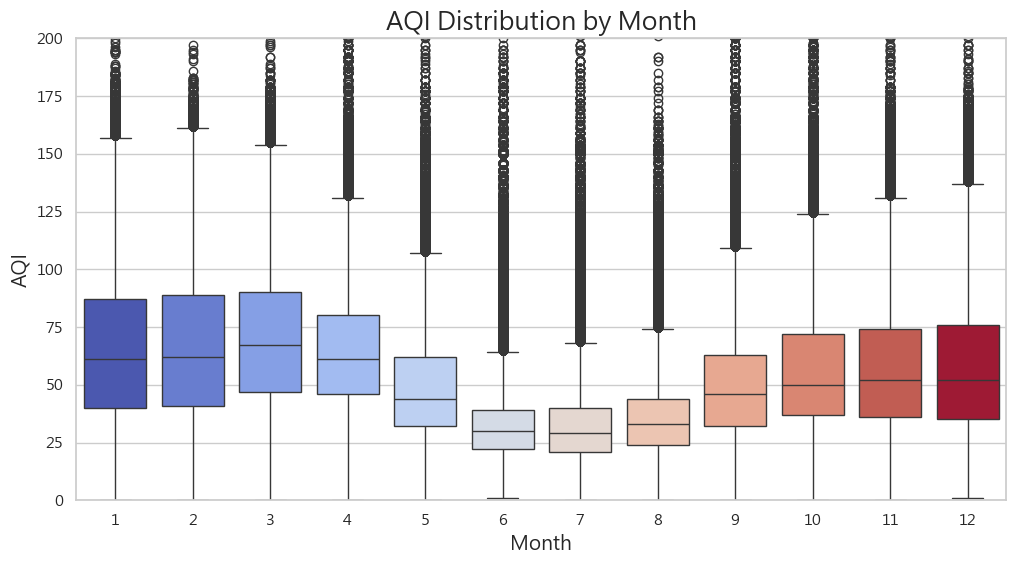

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="month", hue="month", y="aqi", palette="coolwarm", legend=False)
plt.title("AQI Distribution by Month", fontsize=TITLE_FONT_SIZE)
plt.xlabel("Month", fontsize=FONT_SIZE)
plt.ylabel("AQI", fontsize=FONT_SIZE)
plt.ylim(0, 200)
plt.show()

## 🍂 04 — Seasonal Analysis

Verify the mapping of `season_encoded` (Spring=1, Summer=2, Autumn=3, Winter=4) and its correlation with AQI.

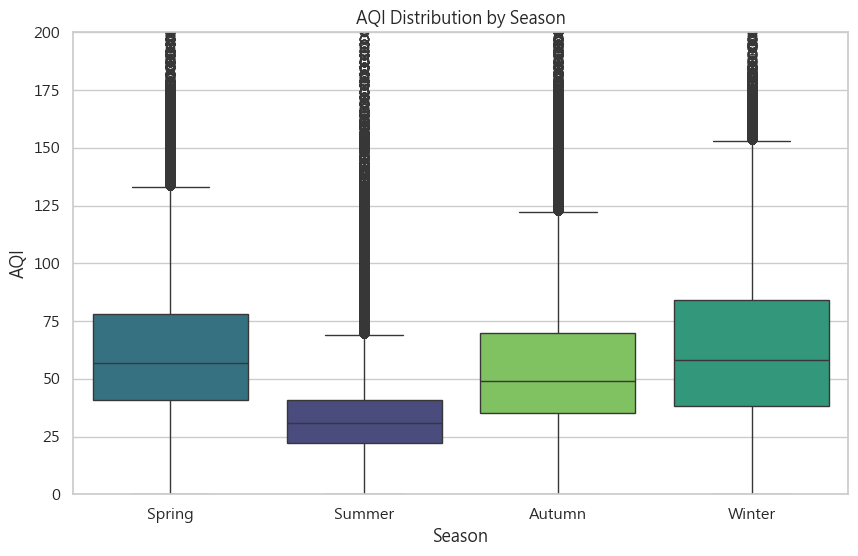

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="season",
    hue="season",
    y="aqi",
    order=["Spring", "Summer", "Autumn", "Winter"],
    palette="viridis",
    legend=False,
)
plt.title("AQI Distribution by Season")
plt.xlabel("Season")
plt.ylabel("AQI")
plt.ylim(0, 200)
plt.show()

---

## 📝 05 — Conclusion

Based on the visualization above, we have confirmed strong seasonality in Taiwan's air quality:

1.  **Monthly Trend**: The AQI distribution follows a distinct **U-shape**.
    - **High Pollution**: Jan - Apr (Winter/Spring)
    - **Low Pollution**: Jun - Aug (Summer)
2.  **Seasonal Impact**:
    - **Winter** and **Spring** show significantly higher median AQI and more extreme outliers.
    - **Summer** has the lowest and most stable AQI levels.

**Impact on Modeling**:
By explicitly providing `month` and `season` features to the LightGBM model, we enable it to adjust its baseline predictions according to the time of year, leading to more robust performance.